<a href="https://colab.research.google.com/github/LavanyaSamineni123/AI-AGENT/blob/main/fastai_ImageClassifier_YourOwn_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fastai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [ ]:
import os, warnings
import numpy as np
import PIL.Image as Image
#import matplotlib.pyplot as plt
from PIL import Image, ImageFile
## from colorama import Fore
from fastai.vision.all import *
from fastai.metrics import accuracy
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

import pathlib, os, torch, gc
import matplotlib.pyplot as plt
from fastai.vision.models import resnet50
from fastai.metrics import error_rate, accuracy
from fastai.vision.all import *


In [ ]:
Image.MAX_IMAGE_PIXELS = 933120000 # Change the max pixels to avoid warnings
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
def loadData(trainPath, valid_pct, bs=None, get_items=get_image_files, get_y=parent_label,
             item_tfms=Resize(224, ResizeMethod.Pad, pad_mode='zeros'), batch_tfms=aug_transforms()):

    # parent_label --> simply gets the name of the folder a file is in

    loader = DataBlock(
        blocks = (ImageBlock, CategoryBlock),
        get_items = get_items,
        splitter = RandomSplitter(valid_pct=valid_pct, seed=24),
        get_y = get_y,
        item_tfms = item_tfms,
        batch_tfms = batch_tfms
    )
    dls = loader.dataloaders(trainPath, bs=bs)
    return dls



In [ ]:
trainPath = '/content/drive/MyDrive/acdataset'


dls = loadData(trainPath, valid_pct=0.2, bs=8, get_y=parent_label)


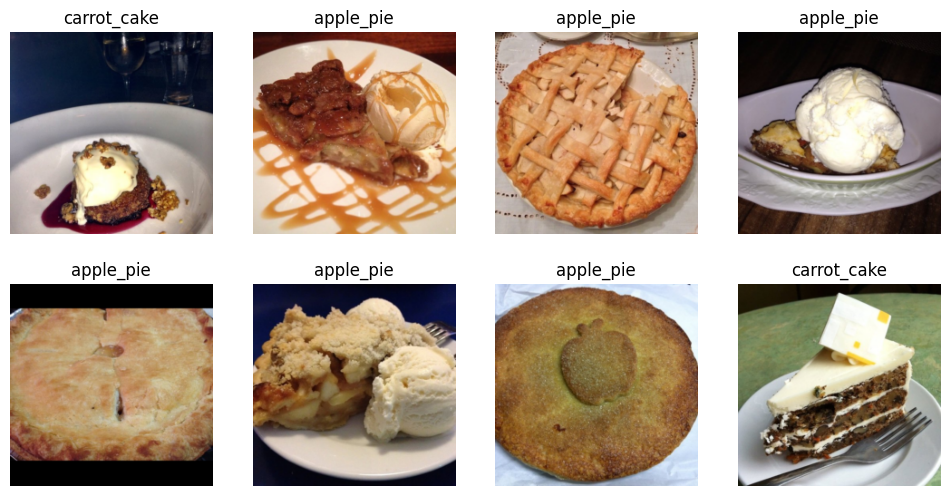

In [ ]:
dls.valid.show_batch(max_n=8, nrows=2)

plt.show()


In [ ]:
def trainModel(dls, arch, path, epoch_ct=1, metrics=[error_rate, accuracy], pretrained=True):

    model   = cnn_learner(dls, arch, metrics=metrics, pretrained=pretrained)
    base_lr = model.lr_find()[0]

    model.fine_tune(epochs=epoch_ct, base_lr = base_lr)
    model.dls.train = dls.train
    model.dls.valid = dls.valid
    model.export(path)
    return model


/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


/usr/local/lib/python3.11/dist-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.930152,0.766358,0.266667,0.733333,05:55


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.609043,0.344602,0.169697,0.830303,08:16
1,0.661167,0.409966,0.163636,0.836364,08:15
2,0.559694,0.320874,0.145455,0.854545,08:14
3,0.607723,0.336388,0.151515,0.848485,08:19
4,0.467271,0.370944,0.157576,0.842424,08:15


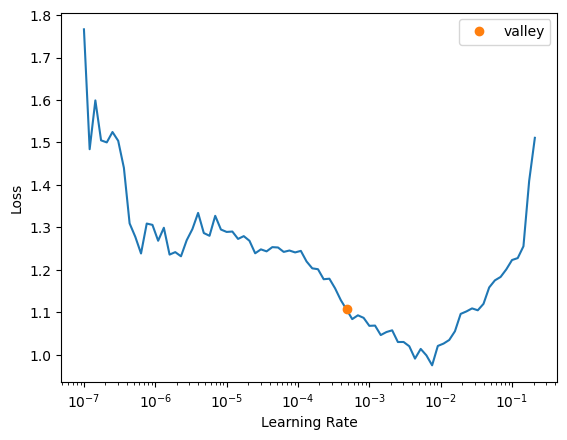

In [ ]:
exportPath = '/content/drive/MyDrive/bestacModel.pkl'

model = trainModel(dls, resnet50, path=exportPath, epoch_ct=5, metrics=[error_rate, accuracy], pretrained=True)

In [ ]:
def confusionMatrix(isModel, model=None, y_true=None, y_pred=None, pos_label=None, neg_label=None):
    if(isModel):
        interp = ClassificationInterpretation.from_learner(model)
        interp.plot_confusion_matrix()
        plt.show()
    else:
        conf_matrix = confusion_matrix(y_true=y_true, y_pred=y_pred)
        fig, ax = plt.subplots(figsize=(7, 5.5))
        ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
        for i in range(conf_matrix.shape[0]):
            for j in range(conf_matrix.shape[1]):
                ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')
        plt.xlabel('Predictions', fontsize=18)
        plt.ylabel('Actuals', fontsize=18)
        plt.title('Confusion Matrix', fontsize=18)
        ax.set_xticklabels([0, neg_label, pos_label])
        ax.set_yticklabels([0, neg_label, pos_label])
        plt.show()



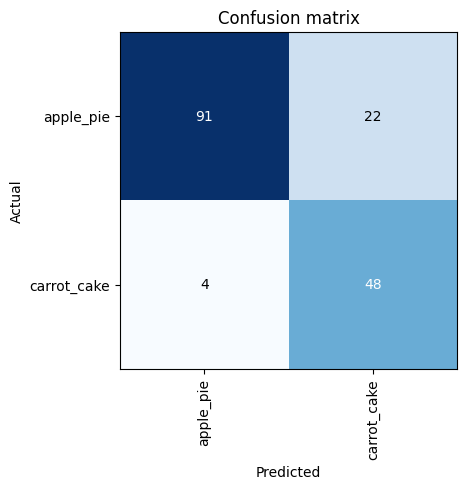

In [ ]:
confusionMatrix(isModel=True, model=model)
